<a href="https://colab.research.google.com/github/mertcandemirr/sql-practice/blob/main/Ke%C5%9Fifci_Veri_Analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid") #sns.set_theme(style=whitegrid)
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 6)

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

In [ ]:
n = 1000

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),
    "yas": np.random.normal(38, 12, n).round(0),
    "gelir": np.random.lognormal(mean=10.5, sigma=0.6, size=n).round(2),
    "sehir": np.random.choice(
        ["İstanbul", "Ankara", "İzmir", "Bursa", "istanbul", "ANKARA"],  # kasıtlı tutarsız yazım
        size=n, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]
    ),
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"], size=n, p=[0.5, 0.35, 0.15]),
    "kayit_tarihi": pd.date_range("2022-01-01", periods=n, freq="7h"),
    "aylik_harcama": np.random.gamma(shape=2, scale=150, size=n).round(2),
    "memnuniyet_puani": np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.1, 0.2, 0.35, 0.3]),
    "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
})

In [ ]:
df.loc[df.sample(frac=0.08, random_state=1).index, "gelir"] = np.nan
df.loc[df.sample(frac=0.05, random_state=2).index, "yas"] = np.nan
df.loc[df.sample(frac=0.03, random_state=3).index, "memnuniyet_puani"] = np.nan
outlier_idx = df.sample(frac=0.01, random_state=4).index
df.loc[outlier_idx, "gelir"] = df["gelir"].max() * np.random.uniform(3, 6, len(outlier_idx))
df.loc[df.sample(frac=0.005, random_state=5).index, "yas"] = -5
df.loc[df.sample(frac=0.005, random_state=6).index, "yas"] = 150
df = pd.concat([df, df.sample(5, random_state=7)], ignore_index=True)

In [ ]:
print(f"Veri Seti :{df.shape[0]} satır, {df.shape[1]} sütun")

Veri Seti :1005 satır, 9 sütun


In [ ]:
df.shape

(1005, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   musteri_id        1005 non-null   int64         
 1   yas               956 non-null    float64       
 2   gelir             926 non-null    float64       
 3   sehir             1005 non-null   object        
 4   abonelik_tipi     1005 non-null   object        
 5   kayit_tarihi      1005 non-null   datetime64[ns]
 6   aylik_harcama     1005 non-null   float64       
 7   memnuniyet_puani  975 non-null    float64       
 8   churn             1005 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 70.8+ KB


In [ ]:
df.head()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,1,44.00,84087.51,Ankara,Temel,2022-01-01 00:00:00,519.21,4.00,0
1,2,36.00,63245.56,İstanbul,Standart,2022-01-01 07:00:00,386.18,2.00,0
2,3,46.00,37638.33,İstanbul,Standart,2022-01-01 14:00:00,1014.04,5.00,0
3,4,56.00,24632.89,İstanbul,Temel,2022-01-01 21:00:00,59.01,5.00,0
4,5,35.00,55211.91,istanbul,Standart,2022-01-02 04:00:00,104.91,2.00,0


In [ ]:
df.tail()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
1000,779,37.00,28068.93,istanbul,Temel,2022-08-15 22:00:00,420.46,4.00,0
1001,335,50.00,39703.73,İstanbul,Premium,2022-04-08 10:00:00,272.02,3.00,0
1002,272,21.00,52338.26,Ankara,Temel,2022-03-21 01:00:00,456.14,3.00,0
1003,803,39.00,23740.93,İstanbul,Standart,2022-08-22 22:00:00,520.06,4.00,0
1004,217,29.00,24243.54,İstanbul,Temel,2022-03-05 00:00:00,838.08,3.00,0


In [ ]:
df.sample(5, random_state=1)

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
685,686,47.00,NaN,İstanbul,Premium,2022-07-19 19:00:00,390.24,3.00,0
614,615,67.00,NaN,İstanbul,Standart,2022-06-29 02:00:00,149.73,4.00,0
602,603,48.00,24647.27,İzmir,Temel,2022-06-25 14:00:00,234.32,4.00,1
502,503,21.00,NaN,İstanbul,Premium,2022-05-27 10:00:00,400.23,4.00,0
341,342,41.00,36381.93,istanbul,Temel,2022-04-10 11:00:00,35.14,4.00,0


In [ ]:
print("\n ---- Sütun Özeti----")
ozet= pd.DataFrame({
    "dtype":df.dtypes,
    "eksik_deger":df.isnull().sum(),
    "unique_deger":df.nunique(),
    "eksik_deger_yuzdesi":(df.isnull().mean()*100).round(2),
})


 ---- Sütun Özeti----


In [ ]:
print(ozet)

                           dtype  eksik_deger  unique_deger  \
musteri_id                 int64            0          1000   
yas                      float64           49            70   
gelir                    float64           79           921   
sehir                     object            0             6   
abonelik_tipi             object            0             3   
kayit_tarihi      datetime64[ns]            0          1000   
aylik_harcama            float64            0           995   
memnuniyet_puani         float64           30             5   
churn                      int64            0             2   

                  eksik_deger_yuzdesi  
musteri_id                       0.00  
yas                              4.88  
gelir                            7.86  
sehir                            0.00  
abonelik_tipi                    0.00  
kayit_tarihi                     0.00  
aylik_harcama                    0.00  
memnuniyet_puani                 2.99  
churn    

In [ ]:
eksik =df.isnull().sum()

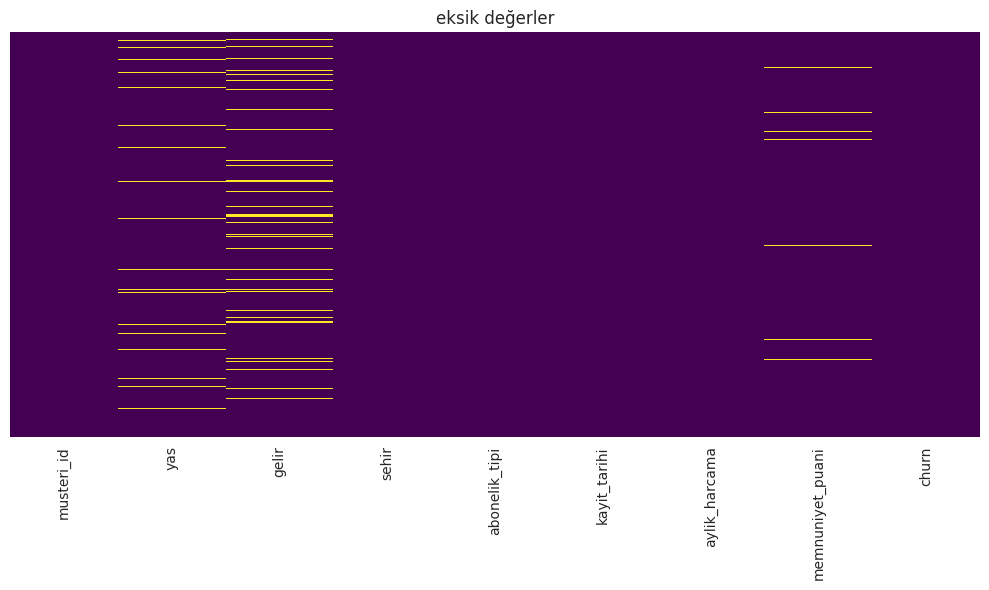

In [ ]:
#eksik değerleri görselleştirelim
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("eksik değerler")
plt.tight_layout()
plt.savefig("eksik_degerler.png", dpi=300)
plt.show()

In [ ]:
n_dup = df.duplicated().sum()

In [ ]:
n_dup

np.int64(5)

In [ ]:
print(df["sehir"].value_counts())

sehir
İstanbul    361
Ankara      190
İzmir       150
Bursa       109
istanbul    101
ANKARA       94
Name: count, dtype: int64


In [ ]:
df["sehir"] = df["sehir"].str.lower().str.strip()

In [ ]:
df["sehir"] = df["sehir"].str.replace('i',"i").str.replace("ı","ı")

In [ ]:
print(df[(df["yas"]< 0)|(df["yas"]>100)][["musteri_id","yas"]])

     musteri_id    yas
11           12  -5.00
22           23 150.00
193         194  -5.00
262         263  -1.00
279         280  -5.00
399         400 150.00
438         439 150.00
515         516  -5.00
544         545  -5.00
909         910 150.00
978         979 150.00


In [ ]:
df.describe()

,musteri_id,yas,gelir,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
count,1005.00,956.00,926.00,1005,1005.00,975.00,1005.00
mean,500.40,38.61,57050.67,2022-05-26 15:49:40.298507520,296.50,3.69,0.18
min,1.00,-5.00,6292.98,2022-01-01 00:00:00,4.54,1.00,0.00
25%,251.00,30.00,25195.60,2022-03-14 22:00:00,148.91,3.00,0.00
50%,500.00,38.00,38028.92,2022-05-26 13:00:00,251.53,4.00,0.00
75%,751.00,46.00,56173.36,2022-08-07 18:00:00,402.07,5.00,0.00
max,1000.00,150.00,1377244.81,2022-10-19 09:00:00,1550.69,5.00,1.00
std,288.67,14.47,120750.24,NaN,205.66,1.12,0.39


In [ ]:
print("\n ---- Çapıklık/BAsıklık----")

sayisal_sutunlar =df.select_dtypes(include=[np.number]).columns.tolist()
sayisal_sutunlar.remove("musteri_id")

for col in sayisal_sutunlar:
  print(f"skew: {df[col].skew():.2f} kurt: {df[col].kurt():.2f}")


 ---- Çapıklık/BAsıklık----
skew: 2.28 kurt: 17.21
skew: 8.95 kurt: 83.96
skew: 1.43 kurt: 3.40
skew: -0.73 kurt: -0.15
skew: 1.63 kurt: 0.67


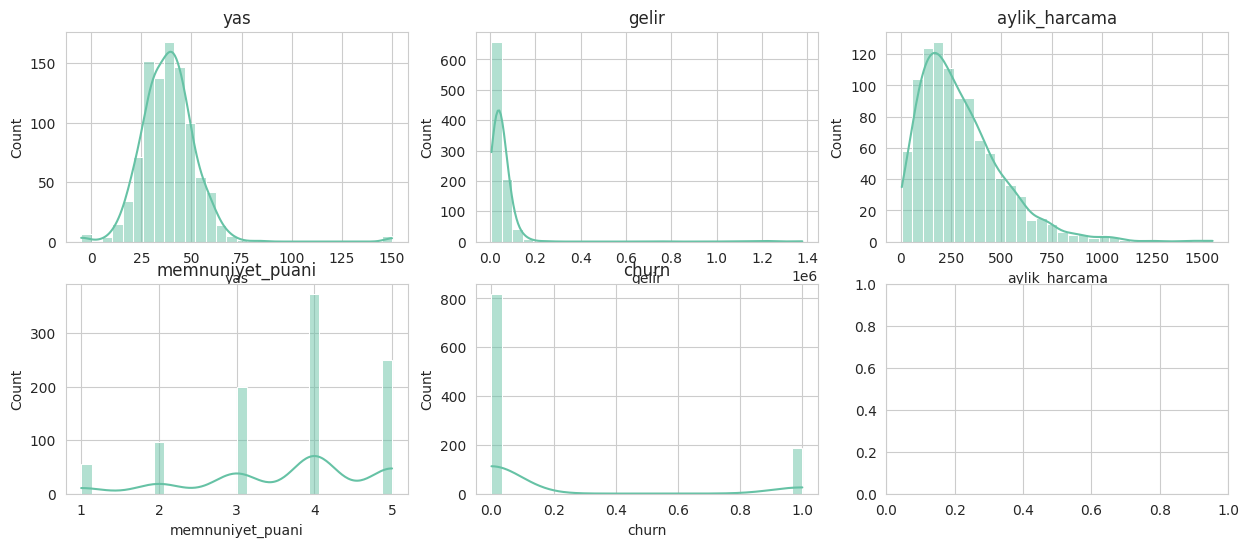

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(15,6))
for ax ,col in zip(axes.flatten(),sayisal_sutunlar):
  sns.histplot(df[col], ax=ax, kde=True,bins =30)
  ax.set_title(col)
plt.tight_layout
plt.savefig("histogramlar.png",dpi = 300)
plt.show ()

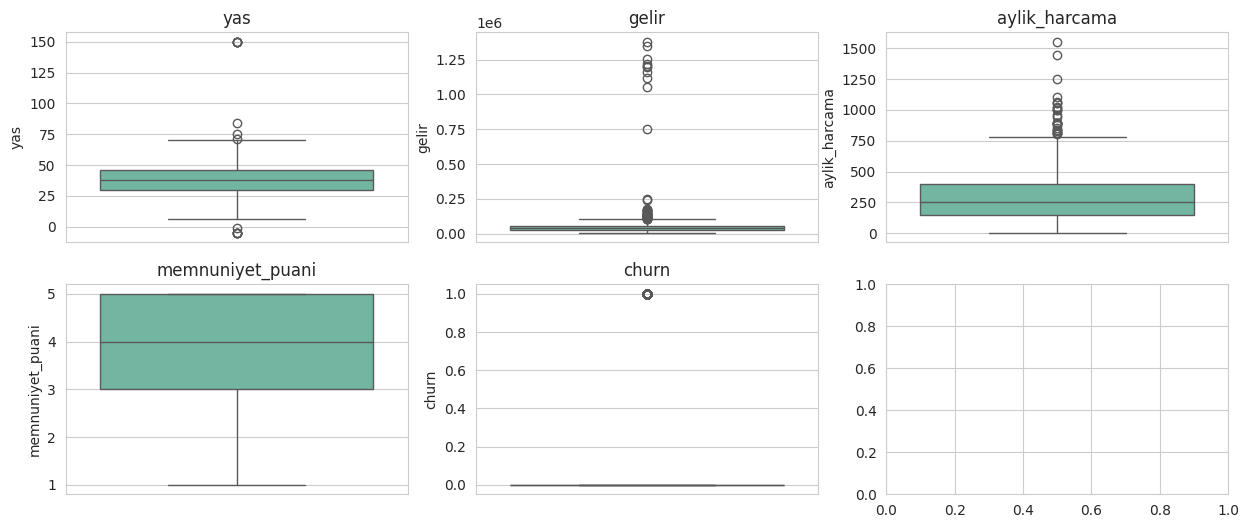

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(15,6))
for ax ,col in zip(axes.flatten(),sayisal_sutunlar):
  sns.boxplot(y=df[col], ax=ax)
  ax.set_title(col)
plt.tight_layout
plt.savefig("boxplot.png",dpi = 300)
plt.show ()

In [ ]:
kategorik_sutünlar = ["sehir","abonelik_tipi","memnuniyet_puani","churn"]
for col in kategorik_sutünlar:

  print((df[col].value_counts(dropna=False, normalize=True)*100).round(2))

sehir
i̇stanbul   35.92
ankara      28.26
i̇zmir      14.93
bursa       10.85
istanbul    10.05
Name: proportion, dtype: float64
abonelik_tipi
Temel      51.74
Standart   35.92
Premium    12.34
Name: proportion, dtype: float64
memnuniyet_puani
4.00   37.21
5.00   24.88
3.00   19.90
2.00    9.55
1.00    5.47
NaN     2.99
Name: proportion, dtype: float64
churn
0   81.59
1   18.41
Name: proportion, dtype: float64


In [ ]:
korelasyon = df[sayisal_sutunlar].corr(numeric_only=True)
print("------ Korelasyon Matrisi-----")
print(korelasyon.round(2))

------ Korelasyon Matrisi-----
                   yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00   0.02          -0.00              0.04  -0.07
gelir             0.02   1.00          -0.04              0.01  -0.04
aylik_harcama    -0.00  -0.04           1.00              0.07  -0.02
memnuniyet_puani  0.04   0.01           0.07              1.00  -0.02
churn            -0.07  -0.04          -0.02             -0.02   1.00


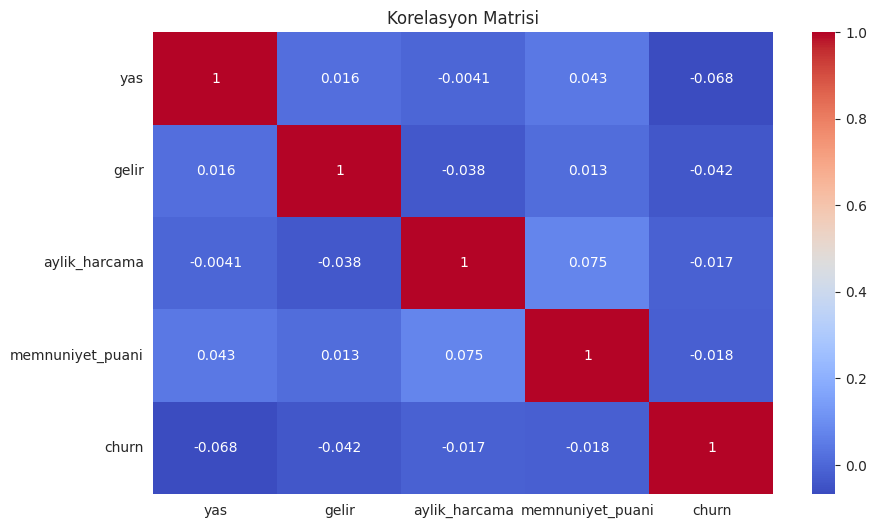

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.tight_layout
plt.savefig("korelasyon_matrisi.png", dpi=300)
plt.show()